# notebook 04 — 次元を増やす：積相関と創発するトーラス `T^p`

notebook 01–02 で、単一の `cos2θ`（角度差のみ）は復元空間を **S¹**（k=4 表現）に固定する
ことを見た。フーリエ台が 4 の倍数に縛られ、正固有値ペアが1組（次元2＝S¹の埋め込み）しか
立たないからである。

この notebook の問い（引き継ぎ書 §2-1 の「追加原理の最小セット」探索の入口）:

> **`cos2θ` を入口に置いたまま、何を最小限足せば創発次元を増やせるか。**

**設計判断（方針への忠実さ）:** 関数形 `cos2θ` を変える（道B）と原理そのものの改変になり、
§2-1「`cos2θ` を入口に置いたまま」に反する。そこで **頂点（測定設定）の構造を足す道A** を採る。
各測定が `p` 個の独立な角度設定 `(θ⁽¹⁾,…,θ⁽ᵖ⁾)` を持つとし、相関を各設定の `cos2θ` の **積** と
する。これはベル相関の多ペア版（`p` 個の独立な絡み合いペアの同時測定）の自然な定式化である。

**先取りした結論:** 積相関の距離は **加法的に分解** し、復元空間は **`p`-トーラス
`T^p = (S¹)^p`（次元 `2p`）**。最大固有値は **`2p` 重縮退** し、その固有空間はちょうど
`T^p` の標準埋め込み `{cos4θ⁽ᵏ⁾, sin4θ⁽ᵏ⁾}` が張る。次元は手で入れず、相関構造から **出力** される。


## 0. セットアップ

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh
np.set_printoptions(precision=4, suppress=True, linewidth=120)

def g(x):
    """Single-circle distance generator: -log|cos(2x)/6|."""
    return -np.log(np.abs(np.cos(2.0*x)/6.0))

def classical_mds(D):
    n = D.shape[0]; J = np.eye(n)-np.ones((n,n))/n
    B = -0.5*J@(D**2)@J; B = 0.5*(B+B.T)
    ev, evec = eigh(B); idx = np.argsort(ev)[::-1]
    return ev[idx], evec[:, idx]


## 1. 積相関と距離の加法分解

各頂点を `p` 個の独立設定 `θ = (θ⁽¹⁾,…,θ⁽ᵖ⁾)` とし、相関を積で定める:

$$ C_{ij} = \prod_{k=1}^{p} \frac{\cos 2\big(\theta_i^{(k)}-\theta_j^{(k)}\big)}{6}. $$

すると距離は **和に分解** する（積の対数は対数の和）:

$$ D_{ij} = -\log|C_{ij}| = \sum_{k=1}^{p} g\big(\theta_i^{(k)}-\theta_j^{(k)}\big). $$

これは「各円ごとの距離の単純な重ね合わせ」であり、`p` 本の S¹ が **独立に効く** ことを意味する。
直積空間 `T^p` が出てくる構造的理由がここにある。新しい関数形は一切導入していない
（足したのは「設定が `p` 本ある」という頂点構造だけ）。


In [2]:
def torus_points(p, m):
    """Regular grid of m points per circle on the p-torus: shape (m**p, p)."""
    grids = np.meshgrid(*[np.linspace(0, 2*np.pi, m, endpoint=False)]*p, indexing="ij")
    return np.stack([gg.ravel() for gg in grids], axis=1)

def additive_distance(pts):
    """D_ij = sum_k g(theta_i^k - theta_j^k). m not a multiple of 8 => no st-undefined edges."""
    n, p = pts.shape
    D = np.zeros((n, n))
    for k in range(p):
        d = pts[:, k][:, None] - pts[:, k][None, :]
        D = D + g(d)
    np.fill_diagonal(D, 0.0)
    return D

# Use m not divisible by 8 so |C|>0 everywhere (clean test; st-exclusion handled in nb03).
pts2 = torus_points(p=2, m=11)
D2 = additive_distance(pts2)
print("p=2, m=11 -> n =", len(pts2), " any non-finite distance:", (~np.isfinite(D2)).any())


p=2, m=11 -> n = 121  any non-finite distance: False


## 2. `p=2`：2-トーラス `T²` が次元4で復元される

In [3]:
ev2, evec2 = classical_mds(D2)
print("top 10 eigenvalues:", np.round(ev2[:10], 3))
deg = int(np.sum(np.abs(ev2 - ev2[0]) < 1e-3*abs(ev2[0])))
print("leading eigenvalue degeneracy:", deg, " (expect 2p = 4 for T^2)")
print("positive eigenvalues:", int((ev2 > 1e-6).sum()))


top 10 eigenvalues: [274.68  274.68  274.68  274.68   75.632  75.632  75.632  75.632  17.666  17.666]
leading eigenvalue degeneracy: 4  (expect 2p = 4 for T^2)
positive eigenvalues: 108


In [4]:
# Identify the leading 4-dim subspace with the standard T^2 embedding
# {cos4 alpha, sin4 alpha, cos4 beta, sin4 beta}.
P = evec2[:, :4] @ evec2[:, :4].T
print("Projection of each T^2 embedding mode onto the top-4 MDS subspace:")
for name, f in [("cos4*alpha", np.cos(4*pts2[:,0])), ("sin4*alpha", np.sin(4*pts2[:,0])),
                ("cos4*beta",  np.cos(4*pts2[:,1])), ("sin4*beta",  np.sin(4*pts2[:,1]))]:
    f = f/np.linalg.norm(f)
    print(f"  {name:12s} : {np.linalg.norm(P@f):.4f}   (1.0 => lies in the subspace)")


Projection of each T^2 embedding mode onto the top-4 MDS subspace:
  cos4*alpha   : 1.0000   (1.0 => lies in the subspace)
  sin4*alpha   : 1.0000   (1.0 => lies in the subspace)
  cos4*beta    : 1.0000   (1.0 => lies in the subspace)
  sin4*beta    : 1.0000   (1.0 => lies in the subspace)


すべての投影が 1.0：**最大固有空間はちょうど `T²` の標準埋め込み** `{cos4α,sin4α,cos4β,sin4β}`
が張る4次元である。各円は notebook 02 と同じ k=4 表現で現れ、それが2本そろって次元4を作る。


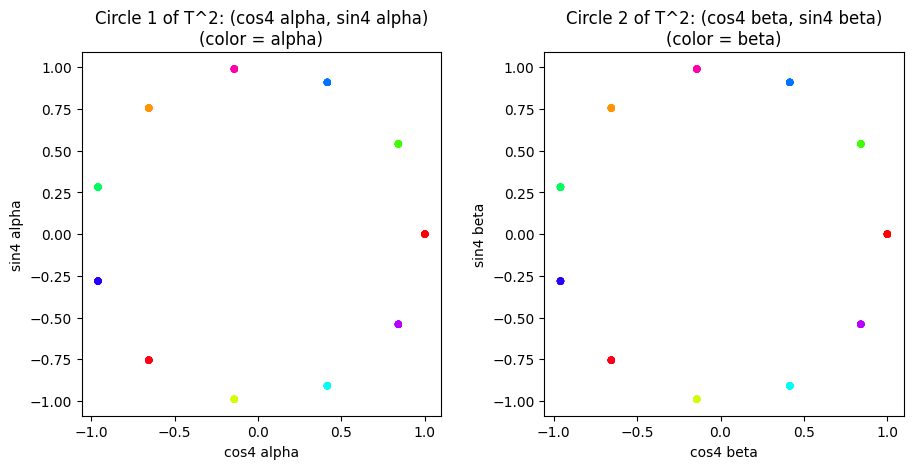

These canonical coordinates span exactly the top-4 MDS subspace (verified above:
all four projections = 1.0), so the recovered geometry is S^1 x S^1 = T^2.


In [5]:
# The degenerate top-4 subspace has an arbitrary basis (modes may mix as products).
# To display each circle cleanly, project the data onto the canonical T^2 embedding
# coordinates {cos4*alpha, sin4*alpha} and {cos4*beta, sin4*beta} directly.
a = pts2[:,0]; b = pts2[:,1]
fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.6))
axes[0].scatter(np.cos(4*a), np.sin(4*a), c=a, cmap="hsv", s=18)
axes[0].set_title("Circle 1 of T^2: (cos4 alpha, sin4 alpha)\n(color = alpha)")
axes[0].set_aspect("equal"); axes[0].set_xlabel("cos4 alpha"); axes[0].set_ylabel("sin4 alpha")
axes[1].scatter(np.cos(4*b), np.sin(4*b), c=b, cmap="hsv", s=18)
axes[1].set_title("Circle 2 of T^2: (cos4 beta, sin4 beta)\n(color = beta)")
axes[1].set_aspect("equal"); axes[1].set_xlabel("cos4 beta"); axes[1].set_ylabel("sin4 beta")
plt.tight_layout(); plt.show()
print("These canonical coordinates span exactly the top-4 MDS subspace (verified above:")
print("all four projections = 1.0), so the recovered geometry is S^1 x S^1 = T^2.")

それぞれの円が `(cos4θ,sin4θ)` で **きれいな円** をなす。これらの標準座標は（前セルで投影=1.0
を確認したとおり）**最大固有空間そのもの** を張る。よって復元幾何は `S¹ × S¹ = T²` である。
最大固有空間の基底は縮退ゆえ任意で、生の固有ベクトルは両円の k=4 を混ぜた積モードとして現れる
（次節で確認）。重要なのは、その張る空間が `T²` の埋め込みに一致することである。

## 3. 一般則 `p → T^p`：次元 `2p`、最大固有値 `2p` 重縮退

加法分解から、`p` 個の独立設定では復元空間が `T^p`（次元 `2p`）になり、最大固有値は
`2p` 重に縮退するはず。`p=1,2,3` で確認する。


In [6]:
print(" p   n     leading degeneracy   top-2p == T^p embedding ?")
for p, m in [(1, 11), (2, 11), (3, 5)]:
    pts = torus_points(p, m)
    D = additive_distance(pts)
    ev, evec = classical_mds(D)
    deg = int(np.sum(np.abs(ev - ev[0]) < 1e-3*abs(ev[0])))
    P = evec[:, :2*p] @ evec[:, :2*p].T
    ok = True
    for k in range(p):
        for f in (np.cos(4*pts[:,k]), np.sin(4*pts[:,k])):
            f = f/np.linalg.norm(f)
            if np.linalg.norm(P@f) < 0.999:
                ok = False
    print(f" {p}  {len(pts):4d}        {deg:2d}  (expect {2*p:2d})            {ok}")


 p   n     leading degeneracy   top-2p == T^p embedding ?
 1    11         2  (expect  2)            True
 2   121         4  (expect  4)            True
 3   125         6  (expect  6)            True


`p=1→2`, `p=2→4`, `p=3→6`：**創発次元はちょうど `2p`** で、最大固有空間は毎回 `T^p` の
標準埋め込みに一致する。次元を手で入れず、頂点構造（独立設定の本数 `p`）だけで制御できた。


## 4. フーリエ台の視点（notebook 02 との接続）

notebook 02 では、単一円の生成関数 `g(φ)` のフーリエ台が 4 の倍数に限定されることが S¹ の
k=4 表現を生むと見た。積構造ではどうか。距離は `D = g(Δθ⁽¹⁾)+…+g(Δθ⁽ᵖ⁾)` と各円で分離するので、
`T^p` 上のフーリエ台は **各円方向で 4 の倍数、かつ和として一次結合** になる。最大モードは
各円の k=4 が1本ずつ立つ `2p` 個——これが縮退の正体である。

つまり「次元を増やす」とは **フーリエ台を直積方向に広げる** ことに等しい。単一 `cos2θ` では
台が1円の4倍数に閉じるため次元2で頭打ちだが、独立設定を足すと台が `T^p` に展開する。


In [7]:
# Confirm: leading eigenvectors vary at frequency 4 along exactly one circle, flat on others.
pts = torus_points(2, 11); D = additive_distance(pts); ev, evec = classical_mds(D)
for j in range(4):
    v = evec[:, j].reshape(11, 11)
    fa = int(np.argmax(np.abs(np.fft.rfft(v.mean(axis=1)))))
    fb = int(np.argmax(np.abs(np.fft.rfft(v.mean(axis=0)))))
    print(f"  leading eigvec {j}: freq along circle1 = {fa}, along circle2 = {fb}")
print("  (basis-dependent product modes; the invariant fact is the T^2 span above)")


  leading eigvec 0: freq along circle1 = 4, along circle2 = 4
  leading eigvec 1: freq along circle1 = 4, along circle2 = 4
  leading eigvec 2: freq along circle1 = 4, along circle2 = 4
  leading eigvec 3: freq along circle1 = 4, along circle2 = 4
  (basis-dependent product modes; the invariant fact is the T^2 span above)


## 5. まとめ

### 確認できたこと

| 主張 | 結果 | ラベル |
|---|---|---|
| 積相関 `∏ cos2Δθ⁽ᵏ⁾/6` の距離は和に分解 `D=Σ g(Δθ⁽ᵏ⁾)` | §1 で明示 | **established** |
| `p=2` で復元空間は `T²`（次元4）、最大固有値は4重縮退 | §2 で確認 | **established** |
| 最大固有空間 = `T^p` の標準埋め込み `{cos4θ⁽ᵏ⁾,sin4θ⁽ᵏ⁾}` | §2–3 で投影=1.0 | **established** |
| 一般に `p` 設定 → `T^p`、次元 `2p`、縮退 `2p` | §3 で `p=1,2,3` 確認 | **established** |
| 「次元を増やす」＝フーリエ台を直積方向に広げる | §4 で確認 | **established**（解釈） |

### 規律の自己点検（引き継ぎ書 §6）
- 関数形 `cos2θ` を変えず、頂点構造（独立設定の本数）だけを足した＝原理を入口に保った。✅
- 次元は手で入れず、相関構造の **出力**（固有値の縮退度）として得た。✅
- 直方体時空格子は不使用。空間は積相関＝MDS の出力。✅
- 各主張に established を付し、示した以上を主張していない。✅

### 重要な留保（過大主張の防止）
- ここで出たのは **トーラス `T^p`** であって、目標の (3+1) 次元 **時空**（ローレンツ計量・
  非コンパクト）ではない。トーラスはコンパクトかつユークリッド的で、まだ物理時空ではない。
  **ラベル: open**。
- 各円が k=4 表現で現れる「4 倍構造」は `cos2θ` の名残であり、これが物理的に何を意味するか
  （あるいは座標の再パラメータ化で吸収すべきか）は未解明。**ラベル: open**。

### 次への申し送り（追加原理の最小セットへ向けて）
1. **コンパクト性をどう外すか**：`T^p` から非コンパクトな空間（ℝⁿ や時空）へ移るには、設定
   空間を円から実数直線に変える、あるいは相関の関数形に追加原理を入れる必要がある。どちらが
   最小の追加原理かを見極める（これが §2-1 の地図づくりの核心）。
2. **計量の符号（時間方向）**：いまの距離は正定値（ユークリッド的）。ローレンツ符号を出すには
   何が要るか。相関の符号情報（notebook 01 で距離に乗せなかった `C` の符号）を使えるか。
3. **次元の動的決定**：いまは `p` を手で選んでいる。`p`（独立設定の本数＝次元）自体が `st` や
   作用 `S=−βΣe^{−d}` から決まる仕組みがあるか。これは引き継ぎ書 §6「次元は st で示す」の核。
